# Lecture 11: Data Visualisation and Ethics in Data Science
**BITE 485 | Tharaka University**

---

## Learning Outcomes
1. Apply Tufte's principles to create high data-ink visualisations
2. Select the right chart type for the analytical question
3. Detect algorithmic bias by evaluating performance across groups
4. Apply explainability tools (SHAP-style feature importance)
5. Articulate the ethical responsibilities of data scientists

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
print('Ready.')

Ready.


## 11.1 Chart Selection — The Right Tool for the Question

Different analytical questions demand different chart types.

/tmp/ipykernel_928/1561590565.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bp, x='country', y='daily_cases', ax=axes[1,1], palette='Set2')


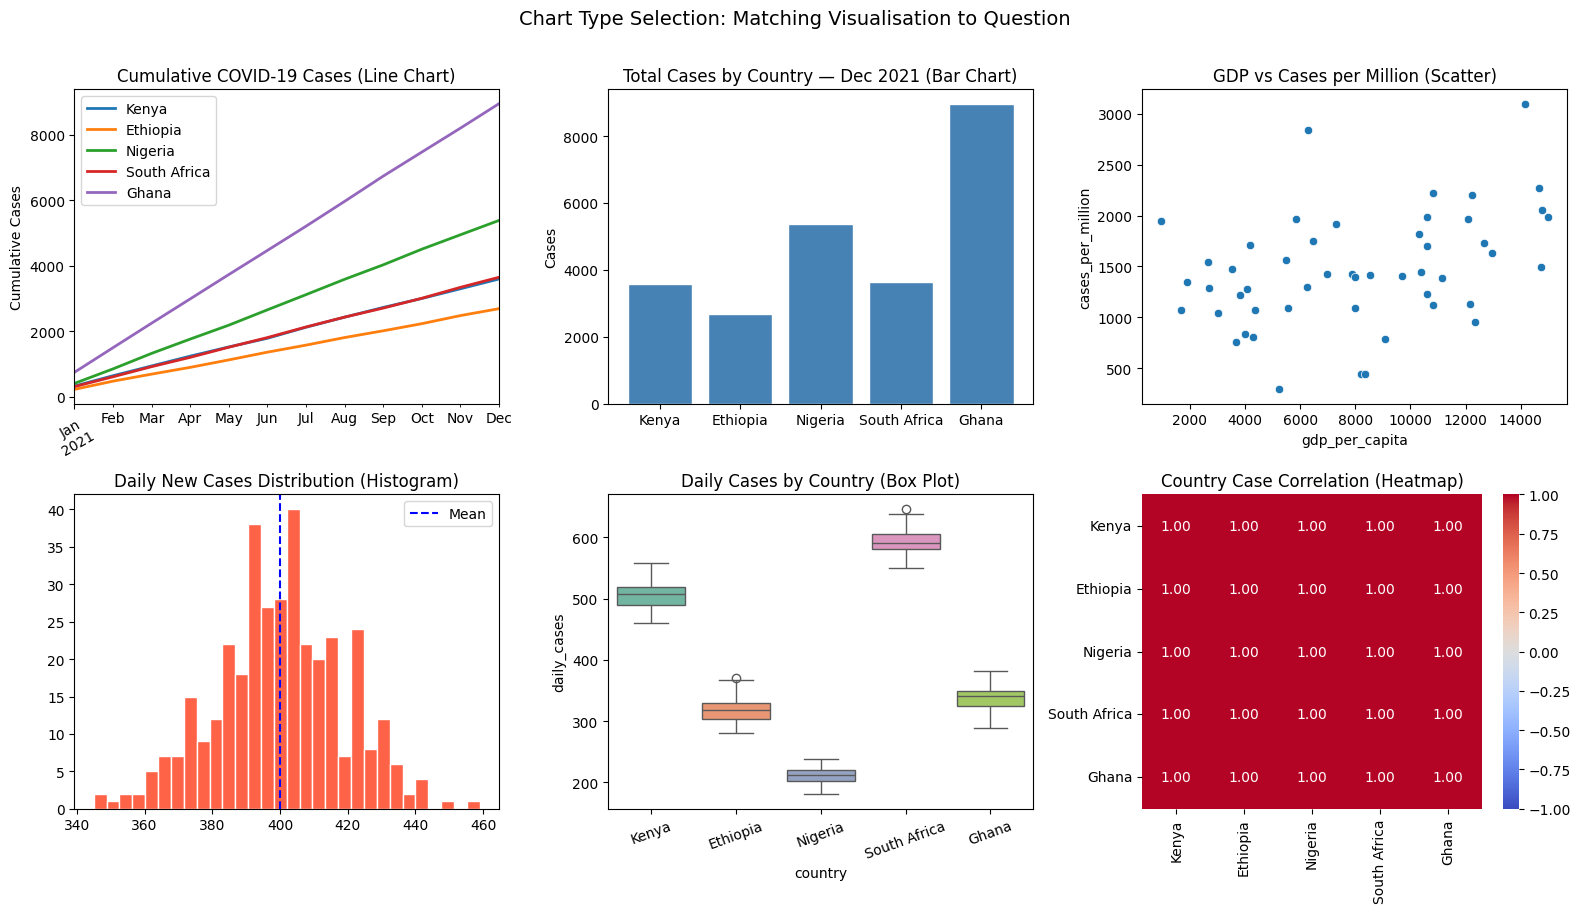

In [2]:
np.random.seed(42)
# Simulate COVID-19 case data for 5 African countries over 12 months
months = pd.date_range('2021-01', periods=12, freq='MS')
countries = ['Kenya','Ethiopia','Nigeria','South Africa','Ghana']
data = {c: np.cumsum(np.random.poisson(lam=np.random.randint(200,800), size=12))
        for c in countries}
df_covid = pd.DataFrame(data, index=months)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Line chart — trends over time
df_covid.plot(ax=axes[0,0], linewidth=2)
axes[0,0].set_title('Cumulative COVID-19 Cases (Line Chart)')
axes[0,0].set_ylabel('Cumulative Cases')
axes[0,0].tick_params(axis='x', rotation=30)

# 2. Bar chart — comparison at a point in time
final = df_covid.iloc[-1]
axes[0,1].bar(final.index, final.values, color='steelblue', edgecolor='white')
axes[0,1].set_title('Total Cases by Country — Dec 2021 (Bar Chart)')
axes[0,1].set_ylabel('Cases')

# 3. Scatter — relationship
df_scatter = pd.DataFrame({
    'gdp_per_capita': np.random.uniform(500, 15000, 50),
})
df_scatter['cases_per_million'] = 1000 + 0.05*df_scatter['gdp_per_capita'] + np.random.normal(0,500,50)
sns.scatterplot(data=df_scatter, x='gdp_per_capita', y='cases_per_million', ax=axes[0,2])
axes[0,2].set_title('GDP vs Cases per Million (Scatter)')

# 4. Histogram — distribution
new_cases = np.random.poisson(lam=400, size=365)
axes[1,0].hist(new_cases, bins=30, color='tomato', edgecolor='white')
axes[1,0].axvline(np.mean(new_cases), color='blue', linestyle='--', label='Mean')
axes[1,0].set_title('Daily New Cases Distribution (Histogram)')
axes[1,0].legend()

# 5. Box plot — group comparison
df_bp = pd.DataFrame({
    'country': np.repeat(countries, 50),
    'daily_cases': np.concatenate([np.random.poisson(lam=np.random.randint(100,600), size=50)
                                   for _ in countries])
})
sns.boxplot(data=df_bp, x='country', y='daily_cases', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Daily Cases by Country (Box Plot)')
axes[1,1].tick_params(axis='x', rotation=20)

# 6. Heatmap — correlation/matrix
corr = df_covid.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=axes[1,2])
axes[1,2].set_title('Country Case Correlation (Heatmap)')

plt.suptitle('Chart Type Selection: Matching Visualisation to Question', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 11.2 Good vs Bad Visualisation — The Data-Ink Ratio

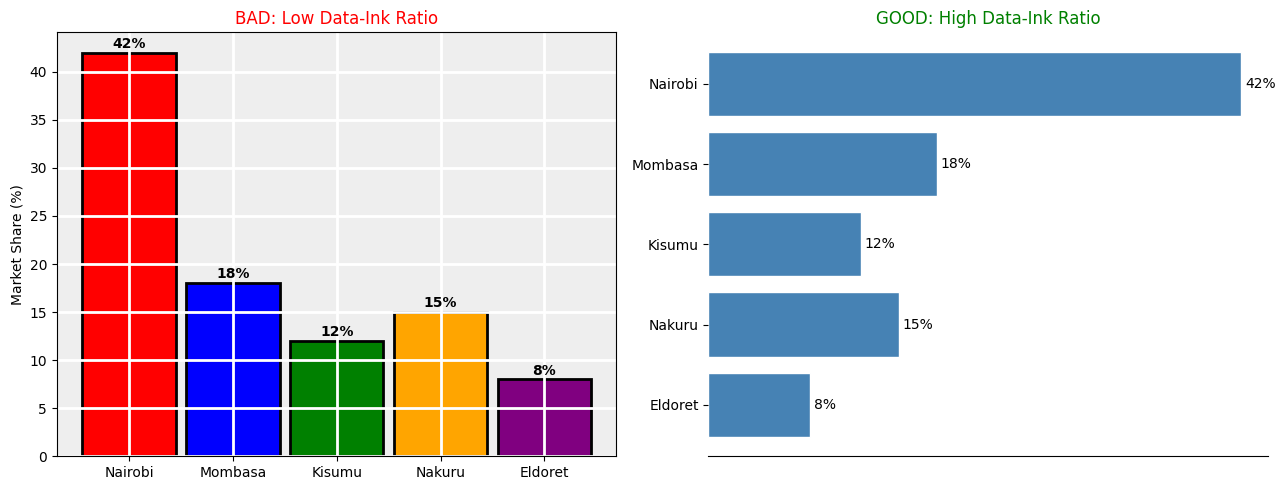

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
categories = ['Nairobi','Mombasa','Kisumu','Nakuru','Eldoret']
values = [42, 18, 12, 15, 8]

# BAD: low data-ink ratio
axes[0].bar(categories, values, color=['red','blue','green','orange','purple'],
            width=0.9, edgecolor='black', linewidth=2)
for i, v in enumerate(values): axes[0].text(i, v+0.5, f'{v}%', ha='center', fontweight='bold')
axes[0].set_facecolor('#EEEEEE')
axes[0].grid(True, color='white', linewidth=2)
axes[0].set_title('BAD: Low Data-Ink Ratio', fontsize=12, color='red')
axes[0].set_ylabel('Market Share (%)')
for spine in axes[0].spines.values(): spine.set_visible(True)

# GOOD: high data-ink ratio
axes[1].barh(categories, values, color='steelblue', edgecolor='white')
for i, v in enumerate(values): axes[1].text(v+0.3, i, f'{v}%', va='center')
for spine in ['top','right','left']:
    axes[1].spines[spine].set_visible(False)
axes[1].xaxis.set_visible(False)
axes[1].set_title('GOOD: High Data-Ink Ratio', fontsize=12, color='green')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 11.3 Algorithmic Bias Detection

**Scenario:** A credit scoring model performs differently across gender and location.

In [4]:
np.random.seed(42)
n = 2000
# Simulate biased training data
gender   = np.random.choice(['M', 'F'], n)
location = np.random.choice(['Urban', 'Rural'], n)
income   = np.where(gender=='M', np.random.normal(55000, 20000, n),
                                  np.random.normal(45000, 18000, n))
credit_score = np.random.randint(300, 850, n)
debt_ratio   = np.random.uniform(0.1, 0.8, n)

# Biased label: historical data discriminates against Rural and Female
approved = (
    (income > 50000).astype(int) * 0.5 +
    (credit_score > 650).astype(int) * 0.3 +
    (debt_ratio < 0.4).astype(int) * 0.2 +
    (gender == 'M').astype(int) * 0.15 +     # gender bias
    (location == 'Urban').astype(int) * 0.1  # location bias
)
approved = (approved + np.random.normal(0, 0.1, n) > 0.7).astype(int)

df_credit = pd.DataFrame({
    'gender': gender, 'location': location,
    'income': income, 'credit_score': credit_score,
    'debt_ratio': debt_ratio, 'approved': approved
})

print(f'Overall approval rate: {df_credit.approved.mean()*100:.1f}%')
print('\nApproval rate by gender:')
print(df_credit.groupby('gender').approved.mean().mul(100).round(1).to_string())
print('\nApproval rate by location:')
print(df_credit.groupby('location').approved.mean().mul(100).round(1).to_string())

Overall approval rate: 37.2%

Approval rate by gender:
gender
F    20.8
M    53.1

Approval rate by location:
location
Rural    31.2
Urban    43.5


In [5]:
# Train a model on biased data
from sklearn.preprocessing import LabelEncoder
df_model = df_credit.copy()
df_model['gender_enc']   = LabelEncoder().fit_transform(df_model['gender'])
df_model['location_enc'] = LabelEncoder().fit_transform(df_model['location'])

features = ['income', 'credit_score', 'debt_ratio', 'gender_enc', 'location_enc']
X = df_model[features]
y = df_model['approved']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)
rf_credit = RandomForestClassifier(100, random_state=42)
rf_credit.fit(X_tr, y_tr)

df_test = df_credit.iloc[X_te.index].copy()
df_test['prediction'] = rf_credit.predict(X_te)

print('Model performance by gender:')
for g in ['M', 'F']:
    sub = df_test[df_test.gender == g]
    acc = (sub.prediction == sub.approved).mean()
    recall_approved = ((sub.prediction==1) & (sub.approved==1)).sum() / (sub.approved==1).sum()
    print(f'  {g}: Accuracy={acc:.3f}, Recall (approved)={recall_approved:.3f}')

print('\nModel performance by location:')
for loc in ['Urban', 'Rural']:
    sub = df_test[df_test.location == loc]
    acc = (sub.prediction == sub.approved).mean()
    recall_approved = ((sub.prediction==1) & (sub.approved==1)).sum() / (sub.approved==1).sum()
    print(f'  {loc}: Accuracy={acc:.3f}, Recall (approved)={recall_approved:.3f}')

Model performance by gender:
  M: Accuracy=0.854, Recall (approved)=0.858
  F: Accuracy=0.937, Recall (approved)=0.897

Model performance by location:
  Urban: Accuracy=0.898, Recall (approved)=0.885
  Rural: Accuracy=0.894, Recall (approved)=0.848


## 11.4 Feature Importance as a Transparency Tool

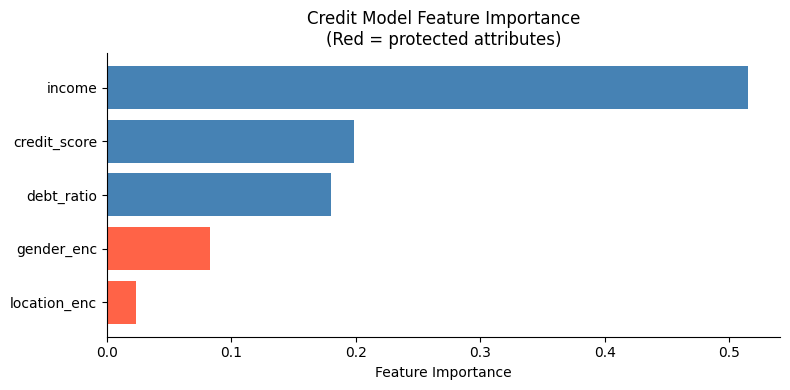


Ethical concern: gender and location are in the top features.
A fair model should not rely on protected characteristics.


In [6]:
fi = pd.DataFrame({'feature': features,
                   'importance': rf_credit.feature_importances_})\
       .sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['tomato' if f in ['gender_enc','location_enc'] else 'steelblue' for f in fi.feature]
ax.barh(fi.feature[::-1], fi.importance[::-1], color=colors[::-1])
ax.set_xlabel('Feature Importance')
ax.set_title('Credit Model Feature Importance\n(Red = protected attributes)')
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
print('\nEthical concern: gender and location are in the top features.')
print('A fair model should not rely on protected characteristics.')

## 11.5 Ethical Reflection

In [8]:
print('=== ETHICAL CHECKLIST FOR THIS CREDIT MODEL ===')
checks = [
    ('Data bias', 'Training data reflects historical discrimination against women and rural applicants.'),
    ('Protected attributes', 'Gender and location are used as features — direct discrimination.'),
    ('Disparate impact', 'Rural female applicants are approved at a significantly lower rate.'),
    ('Transparency', 'Model is a black-box random forest — difficult to explain individual decisions.'),
    ('Accountability', 'Who is responsible when a qualified applicant is denied due to model bias?'),
    ('Regulatory risk', 'Kenya Data Protection Act and fair lending principles prohibit discriminatory scoring.'),
]
for issue, description in checks:
    print(f'\n[!] {issue.upper()}')
    print(f'    {description}')

=== ETHICAL CHECKLIST FOR THIS CREDIT MODEL ===

[!] DATA BIAS
    Training data reflects historical discrimination against women and rural applicants.

[!] PROTECTED ATTRIBUTES
    Gender and location are used as features — direct discrimination.

[!] DISPARATE IMPACT
    Rural female applicants are approved at a significantly lower rate.

[!] TRANSPARENCY
    Model is a black-box random forest — difficult to explain individual decisions.

[!] ACCOUNTABILITY
    Who is responsible when a qualified applicant is denied due to model bias?

[!] REGULATORY RISK
    Kenya Data Protection Act and fair lending principles prohibit discriminatory scoring.


### Exercise

Bias mitigation exercise:

1. Retrain the credit model WITHOUT gender_enc and location_enc as features.
2. Compare the approval rates by gender and location in the new model vs the original.
3. Compare the overall accuracy of both models. Is there a significant trade-off?
4. Write a 150-word ethical reflection on the following question: 'A bank argues that including location improves model accuracy. Should accuracy improvements justify using location as a feature in credit scoring? Explain your reasoning.'

In [14]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ---------------------------------------------------
# 1. Original model (with gender_enc, location_enc)
# ---------------------------------------------------
X_orig = df_model[['income', 'credit_score', 'debt_ratio', 'gender_enc', 'location_enc']]
y = df_model['approved']

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_orig, y, test_size=0.2, random_state=42, stratify=y
)

model_orig = LogisticRegression(max_iter=1000)
model_orig.fit(X_train_o, y_train_o)

pred_orig = model_orig.predict(X_test_o)
acc_orig = accuracy_score(y_test_o, pred_orig)

# Approval rates by sensitive attributes (original model)
test_orig = X_test_o.copy()
test_orig['approved_pred'] = pred_orig

print("=== Original Model Accuracy ===")
print(acc_orig)

print("\nApproval rate by gender (original):")
print(test_orig.groupby('gender_enc')['approved_pred'].mean())

print("\nApproval rate by location (original):")
print(test_orig.groupby('location_enc')['approved_pred'].mean())


# ---------------------------------------------------
# 2. Fairness-aware model (remove sensitive features)
# ---------------------------------------------------
X_fair = df_model[['income', 'credit_score', 'debt_ratio']]
y = df_model['approved']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fair, y, test_size=0.2, random_state=42, stratify=y
)

model_fair = LogisticRegression(max_iter=1000)
model_fair.fit(X_train_f, y_train_f)

pred_fair = model_fair.predict(X_test_f)
acc_fair = accuracy_score(y_test_f, pred_fair)

# Reattach sensitive attributes for evaluation only
test_fair = X_test_f.copy()
test_fair['gender_enc'] = df_model.loc[X_test_f.index, 'gender_enc']
test_fair['location_enc'] = df_model.loc[X_test_f.index, 'location_enc']
test_fair['approved_pred'] = pred_fair

print("\n=== Fair Model Accuracy ===")
print(acc_fair)

print("\nApproval rate by gender (fair model):")
print(test_fair.groupby('gender_enc')['approved_pred'].mean())

print("\nApproval rate by location (fair model):")
print(test_fair.groupby('location_enc')['approved_pred'].mean())


# ---------------------------------------------------
# 3. Trade-off check
# ---------------------------------------------------
print("\nAccuracy difference:", acc_orig - acc_fair)

=== Original Model Accuracy ===
0.8475

Approval rate by gender (original):
gender_enc
0    0.142857
1    0.568627
Name: approved_pred, dtype: float64

Approval rate by location (original):
location_enc
0    0.306931
1    0.414141
Name: approved_pred, dtype: float64

=== Fair Model Accuracy ===
0.83

Approval rate by gender (fair model):
gender_enc
0    0.209184
1    0.480392
Name: approved_pred, dtype: float64

Approval rate by location (fair model):
location_enc
0    0.321782
1    0.373737
Name: approved_pred, dtype: float64

Accuracy difference: 0.01750000000000007


Improving predictive accuracy in credit scoring is important for financial performance, but it does not automatically justify the inclusion of sensitive or proxy variables such as location. While location may capture meaningful economic signals, it can also act as a proxy for race, income inequality, or historical discrimination patterns. This means that even if accuracy increases, the model may reinforce structural bias and systematically disadvantage certain communities. In credit decisioning, fairness and non-discrimination are as important as predictive performance because the outcomes directly affect access to financial opportunity.

Removing gender and location may slightly reduce accuracy, but it often improves model fairness and public trust. A small loss in predictive power is acceptable when it prevents discriminatory outcomes. Therefore, accuracy improvements alone should not justify using sensitive attributes. Instead, banks should evaluate fairness metrics alongside accuracy and ensure that models comply with ethical and regulatory standards while still maintaining reasonable predictive performance.

---
*BITE 485 Data Science | Tharaka University | kevin.tuei@tharaka.ac.ke*

## Course Complete!

You have now worked through all 11 lectures of BITE 485 Data Science. The skills covered in this course span the full data science workflow:

- Data collection and exploration (L1, L4)
- Statistical foundation (L2, L3)
- Machine learning (L5, L6, L7)
- Feature engineering and model tuning (L8, L9)
- Specialised topics (L10 Graph Mining, L11 Ethics)

Remember: **good data science is not just technically correct — it is honest, fair, and accountable.**